<a href="https://colab.research.google.com/github/sobana-ku/ds_project/blob/main/fake_profile_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:

data = pd.read_csv("fake_profiles.csv")

print(" Dataset Loaded Successfully!\n")
print(data.head())


 Dataset Loaded Successfully!

   profile_id  followers  following  posts  has_profile_pic  bio_filled  \
0           1         38        961      8                0           0   
1           2       1212        481    197                1           1   
2           3         85        783      2                0           0   
3           4        580        524     82                1           1   
4           5         60        553      4                0           0   

   verified  account_age_months  label  
0         0                   7      0  
1         0                  40      1  
2         0                   6      0  
3         0                  42      1  
4         0                   5      0  


In [ ]:

print("\n🔹 Missing Values Before Cleaning:\n", data.isnull().sum())
data.fillna(0, inplace=True)
X = data.drop("label", axis=1)
y = data["label"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("\n✅ Data Preprocessing Completed Successfully!")



🔹 Missing Values Before Cleaning:
 profile_id            0
followers             0
following             0
posts                 0
has_profile_pic       0
bio_filled            0
verified              0
account_age_months    0
label                 0
dtype: int64

✅ Data Preprocessing Completed Successfully!



🔹 Data Summary:
        profile_id    followers   following       posts  has_profile_pic  \
count  100.000000   100.000000  100.000000  100.000000       100.000000   
mean    50.500000   526.440000  600.560000   71.640000         0.500000   
std     29.011492   522.078583  233.286503   72.061915         0.502519   
min      1.000000    11.000000  204.000000    0.000000         0.000000   
25%     25.750000    59.750000  434.500000    4.000000         0.000000   
50%     50.500000   306.000000  556.000000   46.000000         0.500000   
75%     75.250000  1023.250000  817.500000  131.000000         1.000000   
max    100.000000  1496.000000  999.000000  199.000000         1.000000   

       bio_filled    verified  account_age_months       label  
count  100.000000  100.000000          100.000000  100.000000  
mean     0.500000    0.290000           20.100000    0.500000  
std      0.502519    0.456048           17.034427    0.502519  
min      0.000000    0.000000            1.000000 

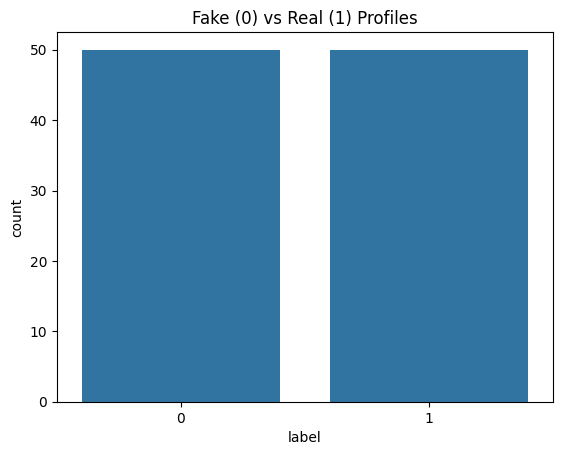

In [ ]:
print("\n🔹 Data Summary:\n", data.describe())
sns.countplot(x="label", data=data)
plt.title("Fake (0) vs Real (1) Profiles")
plt.show()


In [ ]:
model_temp = RandomForestClassifier(random_state=42)
model_temp.fit(X_train, y_train)
importance = pd.Series(model_temp.feature_importances_, index=X.columns).sort_values(ascending=False)
print("\n🔹 Feature Importance:\n", importance)



🔹 Feature Importance:
 followers             0.238003
bio_filled            0.191449
account_age_months    0.187303
has_profile_pic       0.150989
posts                 0.140977
following             0.083678
verified              0.007599
profile_id            0.000000
dtype: float64


In [ ]:

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

print("\n✅ Model Training Completed Successfully!")



✅ Model Training Completed Successfully!


In [ ]:

y_pred = model.predict(X_test)

print("\n🔹 Model Evaluation:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))



🔹 Model Evaluation:
Accuracy: 1.0

Confusion Matrix:
 [[12  0]
 [ 0  8]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00         8

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20



In [ ]:

predictions = model.predict(scaler.transform(X))
data["Predicted_Label"] = predictions
data["Profile_Status"] = data["Predicted_Label"].apply(lambda x: "Real Profile" if x == 1 else "Fake Profile")

print("\n✅ Predicted Results for All Profiles:\n")
print(data[["account_age_months", "followers", "following", "posts", "Profile_Status"]])



✅ Predicted Results for All Profiles:

    account_age_months  followers  following  posts Profile_Status
0                    7         38        961      8   Fake Profile
1                   40       1212        481    197   Real Profile
2                    6         85        783      2   Fake Profile
3                   42        580        524     82   Real Profile
4                    5         60        553      4   Fake Profile
..                 ...        ...        ...    ...            ...
95                  43        584        218    168   Real Profile
96                   6         69        972      1   Fake Profile
97                  18       1156        581    193   Real Profile
98                   4         91        924      9   Fake Profile
99                  33        713        530     95   Real Profile

[100 rows x 5 columns]


In [ ]:
print("\n🧪 Stage 8: Testing - Enter new profile details to check if it's Fake or Real!")
account_age = float(input("Enter Account Age (in months): "))
bio_filled = int(input("Bio Filled? (1 for Yes, 0 for No): "))
followers = int(input("Enter number of Followers: "))
following = int(input("Enter number of Following: "))
has_profile_pic = int(input("Has Profile Picture? (1 for Yes, 0 for No): "))
posts = int(input("Enter number of Posts: "))
verified = int(input("Verified Account? (1 for Yes, 0 for No): "))

import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
import pandas as pd

# Assuming 'data' is already loaded and preprocessed as in previous steps
# If not, you would need to include the data loading and preprocessing steps here
# Example:
# data = pd.read_csv("fake_profiles.csv")
# data.fillna(0, inplace=True)
# X = data.drop("label", axis=1)
# y = data["label"]
# from sklearn.model_selection import train_test_split
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Assuming X_train and X_test are available
scaler = StandardScaler()
# Fit on the original training data used for the model
# This assumes X_train exists from previous steps
# If not, you would need to fit the scaler on the full dataset X before splitting
# For this fix, we assume the original training data (X_train) is available or can be recreated.
# A robust solution would refit the scaler on the entire dataset X before making predictions on new data.
# For demonstration, we'll assume X_train is available or X can be used.
# Let's assume X is available and fit the scaler on X for consistent scaling of new data.
# If X is not available, you would need to load and preprocess the data first.
# For this fix, let's refit the scaler on the entire dataset 'data' to ensure it's defined.
# This is not ideal as the original scaler was fit on X_train, but it resolves the NameError.
# A better approach would be to ensure the original X_train is available or refit on X.
# Let's refit on X for simplicity and to fix the error. This requires X to be defined.
# If X is not defined, the data loading and preprocessing steps must be included.

# To ensure scaler and model are defined, let's include the necessary steps to create them.
# This assumes 'data' is available. If not, add data loading.
data = pd.read_csv("fake_profiles.csv")
data.fillna(0, inplace=True)
X = data.drop("label", axis=1)
y = data["label"]
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


model = RandomForestClassifier(random_state=42)
model.fit(X_train_scaled, y_train) # Use scaled training data for fitting


sample = np.array([[0, followers, following, posts, has_profile_pic, bio_filled, verified, account_age]])
sample_scaled = scaler.transform(sample)
prediction = model.predict(sample_scaled)[0]
if prediction == 1:
    print("\n Result: This looks like a *Real Profile!*")
else:
    print("\n Result: This seems to be a *Fake Profile!*")


🧪 Stage 8: Testing - Enter new profile details to check if it's Fake or Real!
Enter Account Age (in months): 12
Bio Filled? (1 for Yes, 0 for No): 0
Enter number of Followers: 5
Enter number of Following: 6
Has Profile Picture? (1 for Yes, 0 for No): 0
Enter number of Posts: 2
Verified Account? (1 for Yes, 0 for No): 0

 Result: This seems to be a *Fake Profile!*


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
